In [1]:
import glob, os, json, re
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as ss
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.optimize import minimize

sns.set_context('talk')

In [2]:
#what makes good group performance?
#people positively influence each other?
#eg, blame less for partner's risky behavior?

#what makes ppl converge to risky choices that's within tolerance?

In [4]:
folder = "_rep2"
df_group = pd.read_csv(f'../processed_data/parsed_group{folder}.csv', index_col=[0])
# df_group['finalStep'] = np.ceil(df_group['finalStep']/2).astype(int)
df_idv = pd.read_csv(f'../processed_data/parsed_idv{folder}.csv')
# qs = pd.read_csv('../processed_data/parsed_questionnaire_all.csv')


In [5]:
df_group.head()

,attack,selfBlame,jointMoney,partnerStep,playerStep,prediction,split_rt,step_rt,trial,room,block,playerID,predatorType,player_partner_diff,finalStep,subID
0,False,0.50,50.0,4.0,6,-1.0,8.000000,8.000000,1,1,1,1,1,2.0,5.0,16
1,False,0.25,50.0,5.0,4,4.0,3.232899,4.596799,1,1,1,0,1,-1.0,5.0,61
2,True,0.50,18.0,4.0,2,5.0,6.432008,8.000000,2,1,1,1,1,-2.0,3.0,16
3,True,0.75,18.0,2.0,4,5.0,3.516599,2.233400,2,1,1,0,1,2.0,3.0,61
4,False,0.25,18.0,3.0,3,4.0,6.881006,8.000000,3,1,1,1,1,0.0,3.0,16


In [6]:
df_group.columns

Index(['attack', 'selfBlame', 'jointMoney', 'partnerStep', 'playerStep',
       'prediction', 'split_rt', 'step_rt', 'trial', 'room', 'block',
       'playerID', 'predatorType', 'player_partner_diff', 'finalStep',
       'subID'],
      dtype='object')

(array([17., 39., 39., 35., 30., 20., 14.,  8.,  6.,  2.]),
 array([0.05      , 0.43666667, 0.82333333, 1.21      , 1.59666667,
        1.98333333, 2.37      , 2.75666667, 3.14333333, 3.53      ,
        3.91666667]),
 <BarContainer object of 10 artists>)

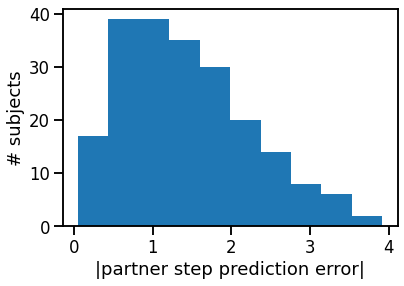

In [7]:
# check prediction error between prediction and partner step. compare people with high vs low prediction error
df_group['pred_error'] = np.abs(df_group['prediction'] - df_group['partnerStep'])
# df_group['pred_error_bin'] = pd.qcut(df_group['pred_error'], q=3, labels=['low', 'med', 'high'])
d = df_group.groupby('subID')['pred_error'].mean().reset_index()
plt.xlabel('|partner step prediction error|')
plt.ylabel('# subjects')
plt.hist(d['pred_error'])

# Model fit

In [39]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize_scalar


class PartnerPredictionModel:
    """
    model_type options
    ------------------
    1: Model A
       Fix alpha = -1, learn beta only
       mu_t = partnerStep_t - attack_t + beta_t * player_partner_diff_t
       beta_{t+1} = beta_t + eta * (partnerStep_{t+1} - mu_t) * player_partner_diff_t

    2: Model B
       Learn alpha and beta with the same learning rate
       mu_t = partnerStep_t + alpha_t * attack_t + beta_t * player_partner_diff_t
       alpha_{t+1} = alpha_t + eta * (partnerStep_{t+1} - mu_t) * attack_t
       beta_{t+1}  = beta_t  + eta * (partnerStep_{t+1} - mu_t) * player_partner_diff_t

    3: Scalar RW
       mu_{t+1} = mu_t + eta * (partnerStep_{t+1} - mu_t)

    4. Model D (win-stay-lose-shift)
   
    """

    def __init__(
        self,
        model_type=1,
        n_squares=9,
        beta0=0.0,
        alpha0=0.0,
        eta=0.05,
        sigma=1.0,
        mu0=None,
    ):
        self.model_type = model_type
        self.n_squares = n_squares
        self.beta = beta0
        self.alpha = alpha0
        self.eta = eta
        self.sigma = sigma
        self.mu = mu0


    def _clip_square(self, x):
        return float(np.clip(x, 1, self.n_squares))

    def expected_step(self, partner_step_t, attack_t, player_partner_diff_t):
        if self.model_type == 1:
            if self.mu is None:
                self.mu = float(partner_step_t)
            mu = self.mu
        elif self.model_type == 2:
            mu = partner_step_t + self.alpha * attack_t + self.beta * player_partner_diff_t
           
        elif self.model_type == 3:
            mu = partner_step_t - attack_t + self.beta * player_partner_diff_t
        
        elif self.model_type == 4:
            direction = 1 - 2 * attack_t
            mu = partner_step_t + self.beta * direction
        return self._clip_square(mu)

    def get_probs(self, mu):
        squares = np.arange(1, self.n_squares + 1)
        logits = -((squares - mu) ** 2) / (2 * self.sigma ** 2)
        logits -= np.max(logits)
        probs = np.exp(logits)
        probs /= probs.sum()
        return probs

    def update(self, partner_step_t, attack_t, player_partner_diff_t, partner_step_next):
        mu_before = self.expected_step(partner_step_t, attack_t, player_partner_diff_t)
        delta = partner_step_next - mu_before

        if self.model_type == 1:
            self.mu = self._clip_square(mu_before + self.eta * delta)

        elif self.model_type == 2:
            self.alpha += self.eta * delta * attack_t
            self.beta += self.eta * delta * player_partner_diff_t

        elif self.model_type == 3:
            self.beta += self.eta * delta * player_partner_diff_t
            
        else:
            direction = 1 - 2 * attack_t
            self.beta += self.eta * delta * direction

        return mu_before, delta
    

    def choose_prediction(self, probs, mode="sample"):
        squares = np.arange(1, self.n_squares + 1)
        if mode == "sample":
            return int(np.random.choice(squares, p=probs))
        elif mode == "argmax":
            return int(squares[np.argmax(probs)])
        elif mode == "mean_round":
            return int(np.clip(np.round(np.sum(squares * probs)), 1, self.n_squares))
        else:
            raise ValueError("mode must be 'sample', 'argmax', or 'mean_round'")


In [40]:

def compute_subject_loglik(
    g,
    model_type,
    eta,
    sigma,
    beta0=0.0,
    alpha0=0.0,
    mu0=None,
    n_squares=9,
    prediction_col="prediction",
):
    """
    Compute log-likelihood of one subject's observed predictions
    under given eta and sigma.
    """
    g = g.sort_values(["predatorType", "trial"]).reset_index(drop=True)

    if prediction_col not in g.columns:
        raise ValueError(f"Data must contain '{prediction_col}' column")

    loglik = 0.0
    n_used = 0

    # fit separately within each predator block/sequence
    for predator, gp in g.groupby("predatorType", sort=False):
        gp = gp.sort_values("trial").reset_index(drop=True)

        model = PartnerPredictionModel(
            model_type=model_type,
            n_squares=n_squares,
            beta0=beta0,
            alpha0=alpha0,
            eta=eta,
            sigma=sigma,
            mu0=mu0,
        )

        for t in range(len(gp)):
            row_t = gp.iloc[t]

            # skip missing observed prediction
            pred_obs = row_t[prediction_col]
            if pd.isna(pred_obs):
                continue

            partner_step_t = row_t["partnerStep"]
            attack_t = row_t["attack"]
            diff_t = row_t["player_partner_diff"]

            mu_t = model.expected_step(partner_step_t, attack_t, diff_t)
            probs_t = model.get_probs(mu_t)

            pred_obs = int(pred_obs)
            if pred_obs < 1 or pred_obs > n_squares:
                continue

            loglik += np.log(probs_t[pred_obs - 1] + 1e-12)
            n_used += 1

            # update using actual next partner behavior, if next trial exists
            if t < len(gp) - 1:
                partner_step_next = gp.loc[t + 1, "partnerStep"]
                model.update(
                    partner_step_t=partner_step_t,
                    attack_t=attack_t,
                    player_partner_diff_t=diff_t,
                    partner_step_next=partner_step_next,
                )

    return loglik, n_used


def fit_eta_sigma_one_subject(
    g,
    model_type,
    beta0=0.0,
    alpha0=0.0,
    mu0=None,
    n_squares=9,
    prediction_col="prediction",
    eta_bounds=(0.0, 1.0),
    sigma_bounds=(1e-3, 10.0),
    eta_init=0.1,
    sigma_init=1.0,
):
    """
    Estimate best-fitting eta and sigma for one participant
    by maximizing log-likelihood.
    """

    if model_type == 3:
        eta_bounds=(0.0, 1.0)
        
    def objective(params):
        eta, sigma = params

        loglik, n_used = compute_subject_loglik(
            g=g,
            model_type=model_type,
            eta=eta,
            sigma=sigma,
            beta0=beta0,
            alpha0=alpha0,
            mu0=mu0,
            n_squares=n_squares,
            prediction_col=prediction_col,
        )

        # minimize negative log-likelihood
        return -loglik


    res = minimize(
        objective,
        x0=np.array([eta_init, sigma_init]),
        bounds=[eta_bounds, sigma_bounds],
        method="L-BFGS-B",
    )

    best_eta, best_sigma = res.x
    best_loglik, n_used = compute_subject_loglik(
        g=g,
        model_type=model_type,
        eta=best_eta,
        sigma=best_sigma,
        beta0=beta0,
        alpha0=alpha0,
        mu0=mu0,
        n_squares=n_squares,
        prediction_col=prediction_col,
    )

    k = 2  # eta and sigma
    aic = 2 * k - 2 * best_loglik if n_used > 0 else np.nan
    bic = k * np.log(n_used) - 2 * best_loglik if n_used > 0 else np.nan

    return {
        "eta_hat": best_eta,
        "sigma_hat": best_sigma,
        "loglik": best_loglik,
        "n_obs": n_used,
        "AIC": aic,
        "BIC": bic,
        # "success": res.success,
    }


def fit_eta_sigma_all_subjects(
    df,
    model_type,
    beta0=0.0,
    alpha0=0.0,
    mu0=None,
    n_squares=9,
    prediction_col="prediction",
    eta_bounds=(0.0, 1.0),
    sigma_bounds=(1e-3, 10.0),
    eta_init=0.1,
    sigma_init=1.0,
):
    """
    Fit best eta and sigma for each participant (subID).
    """

    # if model_type == 1:
    #     eta_bounds=(0.0, 1.0)
    required_cols = [
        "subID", "predatorType", "trial",
        "partnerStep", "attack", "player_partner_diff",
        prediction_col
    ]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    results = []

    for sub, g in df.groupby("subID", sort=False):
        out = fit_eta_sigma_one_subject(
            g=g,
            model_type=model_type,
            beta0=beta0,
            alpha0=alpha0,
            mu0=mu0,
            n_squares=n_squares,
            prediction_col=prediction_col,
            eta_bounds=eta_bounds,
            sigma_bounds=sigma_bounds,
            eta_init=eta_init,
            sigma_init=sigma_init,
        )

        results.append({
            "subID": sub,
            "model_type": model_type,
            **out
        })

    return pd.DataFrame(results)

In [11]:

fit_A = fit_eta_sigma_all_subjects(
    df_group,
    model_type=1,
    beta0=0.0,
)

In [12]:
fit_B = fit_eta_sigma_all_subjects(
    df_group,
    model_type=2,
    beta0=0.0,
)

In [13]:
fit_C = fit_eta_sigma_all_subjects(
    df_group,
    model_type=3,
    beta0=0.0,
)

In [14]:
fit_D = fit_eta_sigma_all_subjects(
    df_group,
    model_type=4,
    beta0=0.0,
)

In [15]:
from functools import reduce

fits = {
    "A": fit_A,
    "B": fit_B,
    "C": fit_C,
    "D": fit_D,
}

df_flat = reduce(
    lambda left, right: pd.merge(left, right, on="subID", how="inner"),
    [
        df[["subID", "loglik", "AIC", "BIC"]].rename(
            columns={
                "loglik": f"loglik_{name}",
                "AIC": f"AIC_{name}",
                "BIC": f"BIC_{name}",
            }
        )
        for name, df in fits.items()
    ],
)

A vs B: stat=2547.0, p=6.256159007711491e-22, mean delta BIC=-17.929881570788304
A vs C: stat=864.0, p=4.921520624772868e-31, mean delta BIC=-27.1642666882974
A vs D: stat=578.0, p=1.6037671857560791e-32, mean delta BIC=-25.46649988636581
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

A vs. B: Wilcoxon test (paired samples), P_val:6.256e-22 Stat=2.547e+03
A vs. C: Wilcoxon test (paired samples), P_val:4.922e-31 Stat=8.640e+02
A vs. D: Wilcoxon test (paired samples), P_val:1.604e-32 Stat=5.780e+02


/var/folders/pz/7dj8ydn13nl3v61r2ph397lh0000gn/T/ipykernel_12437/2176151082.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


(<Axes: ylabel='BIC'>,
  <statannotations.Annotation.Annotation at 0x7fef28fa0d00>])

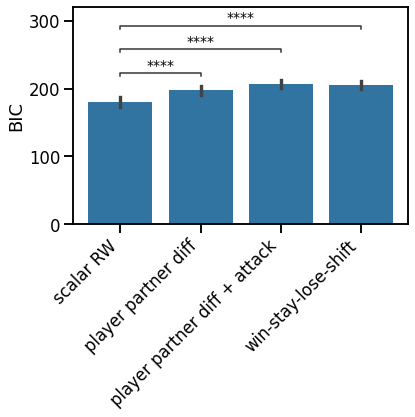

In [87]:
# plot bic
df_long = df_flat.melt(id_vars="subID", value_vars=["BIC_A", "BIC_B", "BIC_C", "BIC_D"], 
                         var_name="model", value_name="BIC")
ax = sns.barplot(df_long, x="model", y="BIC")
ax.set_xticklabels(
    ['scalar RW', 
     'player partner diff', 
     'player partner diff + attack', 
     'win-stay-lose-shift'],
    rotation=45,
    ha='right'
)
ax.set_xlabel('')

# test significance of deltaBIC between models A and C, and between B and C
from scipy.stats import wilcoxon
for num in ["B", "C", "D"]:
    df_flat[f"delta_A_{num}"] = df_flat["BIC_A"] - df_flat[f"BIC_{num}"]
    stat_A, p_A = wilcoxon(df_flat[f"delta_A_{num}"]) # A vs {num}
    print(f"A vs {num}: stat={stat_A}, p={p_A}, mean delta BIC={df_flat[f'delta_A_{num}'].mean()}")

# annotate significance on plot: use annotate package
from statannotations.Annotator import Annotator
df_long["model"] = df_long["model"].str.replace("BIC_", "")
pairs = [
    ("A", "B"),
    ("A", "C"),
    ("A", "D"),
]

annotator = Annotator(
    ax,
    pairs,
    data=df_long,
    x="model",
    y="BIC"
)

annotator.configure(
    test="Wilcoxon",
    text_format="star",   # or "simple"
    loc="inside",
    verbose=2,
    fontsize=14,
)

annotator.apply_and_annotate()

# Model Simulation

In [41]:
def simulate_predictions(
    df,
    params_df,
    model_type,
    n_squares=9,
    choice_mode="sample",
    default_eta=0.05,
    default_beta0=0.0,
    default_alpha0=0.0,
    default_mu0=None,
    default_sigma=1.0,
):
    """
    Simulate trial-by-trial predictions using each subject's fitted parameters.

    Parameters
    ----------
    df : pd.DataFrame
        Trial-level data. Must contain:
        subID, predatorType, trial, partnerStep, attack, player_partner_diff
        Optional: prediction

    params_df : pd.DataFrame
        Subject-level parameter table. Must contain:
        subID
        Optional fitted columns:
            eta_hat, beta0_hat, alpha0_hat, mu0_hat, sigma_hat

    model_type : int
        1, 2, or 3

    Returns
    -------
    sim_df : pd.DataFrame
        Trial-level simulated predictions and latent states
    """
    required_cols = ["subID", "predatorType", "trial", "partnerStep", "attack", "player_partner_diff"]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns in df: {missing}")

    if "subID" not in params_df.columns:
        raise ValueError("params_df must contain 'subID'")

    df = df.copy()
    params_df = params_df.copy()

    # merge subject-level params into trial-level df
    merged = df.merge(params_df, on="subID", how="left")
    merged = merged.sort_values(["subID", "predatorType", "trial"]).reset_index(drop=True)

    all_rows = []

    for i, ((sub, predator), g) in enumerate(merged.groupby(["subID", "predatorType"], sort=False)):
        g = g.sort_values("trial").reset_index(drop=True)


        # pull subject-specific fitted params if available
        first_row = g.iloc[0]

        eta_sub = first_row["eta_hat"] if "eta_hat" in g.columns and pd.notna(first_row["eta_hat"]) else default_eta
        beta0_sub = first_row["beta0_hat"] if "beta0_hat" in g.columns and pd.notna(first_row["beta0_hat"]) else default_beta0
        alpha0_sub = first_row["alpha0_hat"] if "alpha0_hat" in g.columns and pd.notna(first_row["alpha0_hat"]) else default_alpha0
        mu0_sub = first_row["mu0_hat"] if "mu0_hat" in g.columns and pd.notna(first_row["mu0_hat"]) else default_mu0
        sigma_sub = first_row["sigma_hat"] if "sigma_hat" in g.columns and pd.notna(first_row["sigma_hat"]) else default_sigma

        model = PartnerPredictionModel(
            model_type=model_type,
            n_squares=n_squares,
            beta0=beta0_sub,
            alpha0=alpha0_sub,
            eta=eta_sub,
            sigma=sigma_sub,
            mu0=mu0_sub,
            # random_state=random_state + i,
        )

        for t in range(len(g)):
            row_t = g.iloc[t]

            partner_step_t = row_t["partnerStep"]
            attack_t = row_t["attack"]
            diff_t = row_t["player_partner_diff"]

            if pd.isna(partner_step_t) or pd.isna(attack_t) or pd.isna(diff_t):
                continue

            alpha_before = model.alpha if model_type in [2, 3, 4] else np.nan
            beta_before = model.beta if model_type in [2, 3, 4] else np.nan
            mu_state_before = model.mu if model_type == 1 else np.nan

            mu_t = model.expected_step(partner_step_t, attack_t, diff_t)
            probs_t = model.get_probs(mu_t)
            pred_sim = model.choose_prediction(probs_t, mode=choice_mode)

            rec = {
                "subID": sub,
                "predatorType": predator,
                "trial": row_t["trial"],
                "model_type": model_type,

                # fitted params actually used
                "eta_used": eta_sub,
                "beta0_used": beta0_sub,
                "alpha0_used": alpha0_sub,
                "mu0_used": mu0_sub,
                "sigma_used": sigma_sub,

                # trial inputs
                "partnerStep_t": partner_step_t,
                "attack_t": attack_t,
                "player_partner_diff_t": diff_t,

                # latent state before update
                "alpha_before": alpha_before,
                "beta_before": beta_before,
                "mu_state_before": mu_state_before,

                # current prediction distribution
                "mu_pred": mu_t,
                "prediction_sim": pred_sim,
                "prediction_argmax": int(np.argmax(probs_t) + 1),
            }

            if "prediction" in g.columns:
                rec["prediction_obs"] = row_t["prediction"]
                pred_obs = row_t["prediction"]
                if pd.notna(pred_obs) and 1 <= int(pred_obs) <= n_squares:
                    rec["loglik_prediction_obs"] = np.log(probs_t[int(pred_obs) - 1] + 1e-12)
                else:
                    rec["loglik_prediction_obs"] = np.nan

            for k, p in enumerate(probs_t, start=1):
                rec[f"p_square_{k}"] = p

            # update using actual next partner behavior if next trial exists
            if t < len(g) - 1:
                partner_step_next = g.loc[t + 1, "partnerStep"]

                _, delta_t = model.update(
                    partner_step_t=partner_step_t,
                    attack_t=attack_t,
                    player_partner_diff_t=diff_t,
                    partner_step_next=partner_step_next,
                )

                rec["partnerStep_next"] = partner_step_next
                rec["delta"] = delta_t
                # rec["alpha_after"] = state_after["alpha"] if state_after["alpha"] is not None else np.nan
                # rec["beta_after"] = state_after["beta"] if state_after["beta"] is not None else np.nan
                # rec["mu_state_after"] = state_after["mu"] if state_after["mu"] is not None else np.nan

            else:
                rec["partnerStep_next"] = np.nan
                rec["delta"] = np.nan
                # rec["alpha_after"] = model.alpha if model_type == 2 else (-1.0 if model_type == 1 else np.nan)
                # rec["beta_after"] = model.beta if model_type in [1, 2] else np.nan
                # rec["mu_state_after"] = model.mu if model_type == 3 else np.nan

            all_rows.append(rec)

    return pd.DataFrame(all_rows)

In [42]:
sim_A = simulate_predictions(
    df=df_group,
    params_df=fit_A,
    model_type=1,
    choice_mode="sample",
    default_beta0=0.0,

    
    default_sigma=1.0
)
sim_A.head()

,subID,predatorType,trial,model_type,eta_used,beta0_used,alpha0_used,mu0_used,sigma_used,partnerStep_t,...,p_square_2,p_square_3,p_square_4,p_square_5,p_square_6,p_square_7,p_square_8,p_square_9,partnerStep_next,delta
0,0,0,1,1,0.242698,0.0,0.0,None,2.76104,3.0,...,0.167111,0.178439,0.167111,0.137262,0.098884,0.062479,0.034624,0.016829,3.0,0.000000
1,0,0,2,1,0.242698,0.0,0.0,None,2.76104,3.0,...,0.167111,0.178439,0.167111,0.137262,0.098884,0.062479,0.034624,0.016829,3.0,0.000000
2,0,0,3,1,0.242698,0.0,0.0,None,2.76104,3.0,...,0.167111,0.178439,0.167111,0.137262,0.098884,0.062479,0.034624,0.016829,1.0,-2.000000
3,0,0,4,1,0.242698,0.0,0.0,None,2.76104,1.0,...,0.186123,0.186479,0.163868,0.126295,0.085371,0.050614,0.026318,0.012003,3.0,0.485395
4,0,0,5,1,0.242698,0.0,0.0,None,2.76104,3.0,...,0.181587,0.184768,0.164893,0.129064,0.088602,0.053347,0.028171,0.013048,3.0,0.367591


In [43]:
sim_B = simulate_predictions(
    df=df_group,
    params_df=fit_B,
    model_type=2,
    choice_mode="sample",
    default_beta0=0.0,
    default_sigma=1.0
)

In [60]:
sim_C = simulate_predictions(
    df=df_group,
    params_df=fit_C,
    model_type=3,
    choice_mode="sample",
    default_beta0=0.0,
    default_sigma=1.0
)


In [61]:
sim_D = simulate_predictions(
    df=df_group,
    params_df=fit_C,
    model_type=4,
    choice_mode="sample",
    default_beta0=0.0,
    default_sigma=1.0
)
sim_C.head()

,subID,predatorType,trial,model_type,eta_used,beta0_used,alpha0_used,mu0_used,sigma_used,partnerStep_t,...,p_square_2,p_square_3,p_square_4,p_square_5,p_square_6,p_square_7,p_square_8,p_square_9,partnerStep_next,delta
0,0,0,1,3,0.044709,0.0,0.0,None,2.8798,3.0,...,0.199250,0.187592,0.156554,0.115810,0.075938,0.044138,0.022740,0.010385,3.0,1.000000
1,0,0,2,3,0.044709,0.0,0.0,None,2.8798,3.0,...,0.146961,0.164740,0.163693,0.144175,0.112561,0.077896,0.047783,0.025982,3.0,-0.447091
2,0,0,3,3,0.044709,0.0,0.0,None,2.8798,3.0,...,0.164059,0.174034,0.163643,0.136394,0.100769,0.065992,0.038308,0.019711,1.0,-1.989473
3,0,0,4,3,0.044709,0.0,0.0,None,2.8798,1.0,...,0.229721,0.191712,0.141818,0.092992,0.054050,0.027847,0.012717,0.005148,3.0,2.000000
4,0,0,5,3,0.044709,0.0,0.0,None,2.8798,3.0,...,0.160720,0.172349,0.163825,0.138034,0.103092,0.068249,0.040050,0.020832,3.0,-0.079362


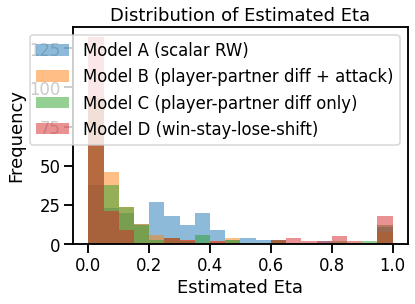

In [62]:
plt.hist(fit_A['eta_hat'], bins=20, alpha=0.5, label='Model A (scalar RW)')
plt.hist(fit_B['eta_hat'], bins=20, alpha=0.5, label='Model B (player-partner diff + attack)')
plt.hist(fit_C['eta_hat'], bins=20, alpha=0.5, label='Model C (player-partner diff only)')
plt.hist(fit_D['eta_hat'], bins=20, alpha=0.5, label='Model D (win-stay-lose-shift)')
plt.xlabel('Estimated Eta')
plt.ylabel('Frequency')
plt.title('Distribution of Estimated Eta')
plt.legend()
plt.show()

In [46]:
def plot_trial_predictions(subset):
    fig, axes = plt.subplots(6, 10, figsize=(20, 10), sharey=True)
    axes = axes.flatten()
    for t in range(len(subset)):
        row = subset.iloc[t]
        probs = [row[f"p_square_{k}"] for k in range(1, 10)]
        axes[t].bar(np.arange(1, 10), probs, alpha=0.5, label=f'Trial {row["trial"]}')
        axes[t].axvline(row["partnerStep_t"], color='red', linestyle='-', label='Actual Partner Step')
        axes[t].axvline(row["prediction_obs"], color='black', linestyle='--', label='Actual Prediction')
        axes[t].axvline(row["prediction_argmax"], color='lightblue', linestyle='--', label='Predicted Best')
        axes[t].set_title(f'Trial {row["trial"]}')
        axes[t].set_xlabel('')
        axes[t].set_ylabel('')
        axes[t].legend().remove()
    plt.show()

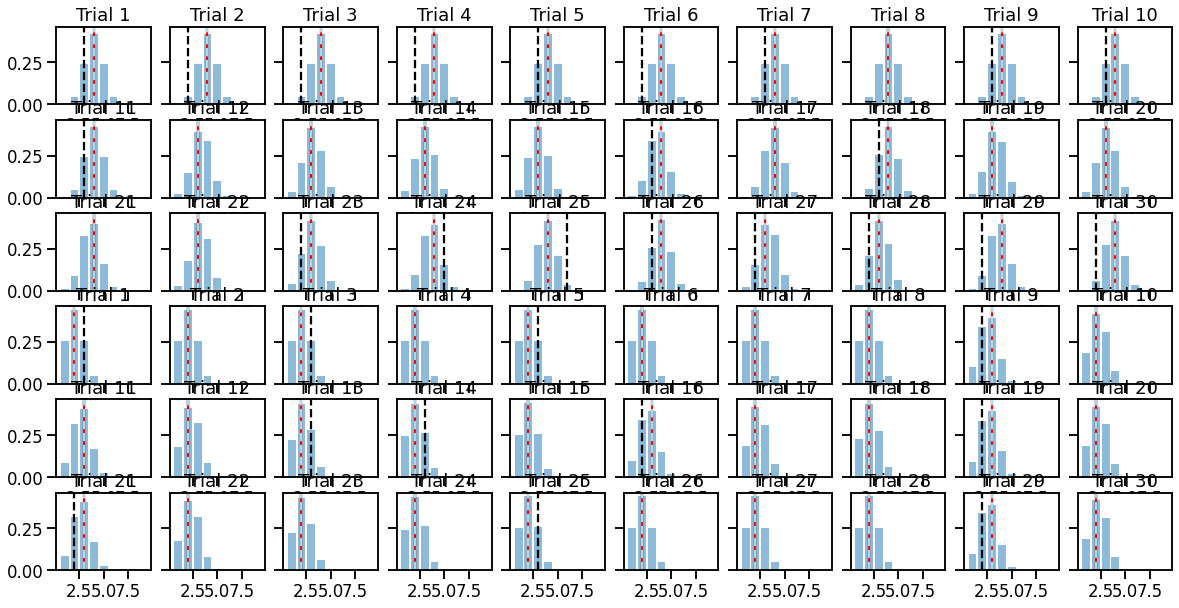

In [47]:
subset = sim_A.query('subID==40')
#for each trial, plot the predicted distribution and the actual partner step
plot_trial_predictions(subset)


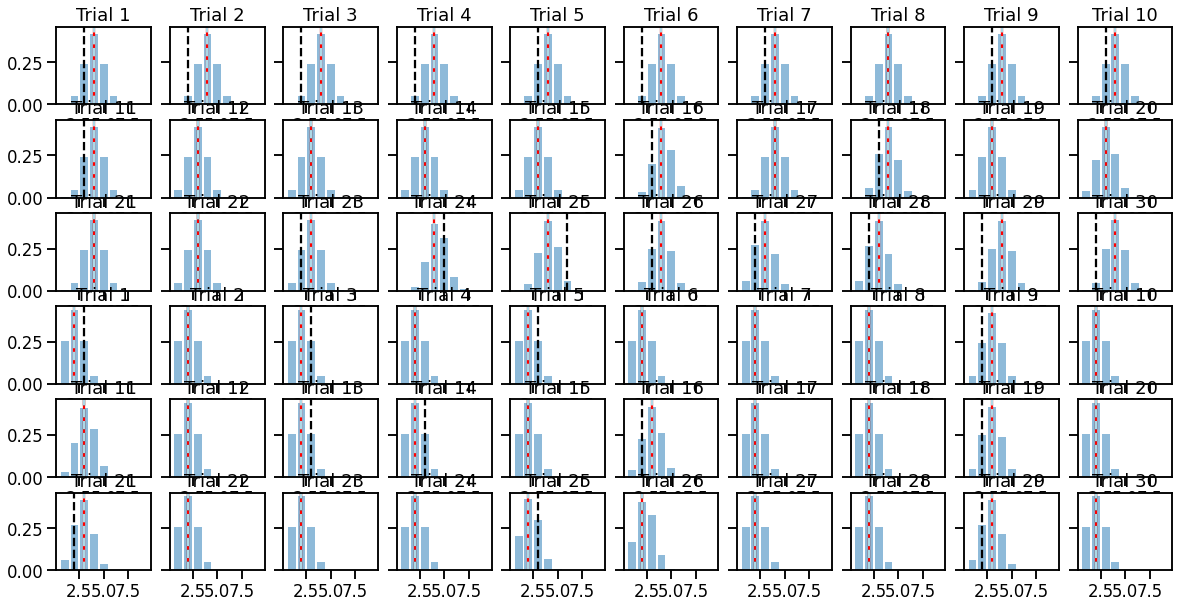

In [48]:
subset = sim_B.query('subID==40')
plot_trial_predictions(subset)

In [ ]:
# save
sim_A.to_csv(f"../model_fits/rl{folder}/simulated_predictions{folder}.csv", index=False)

In [52]:
sim_A.columns

Index(['subID', 'predatorType', 'trial', 'model_type', 'eta_used',
       'beta0_used', 'alpha0_used', 'mu0_used', 'sigma_used', 'partnerStep_t',
       'attack_t', 'player_partner_diff_t', 'alpha_before', 'beta_before',
       'mu_state_before', 'mu_pred', 'prediction_sim', 'prediction_argmax',
       'prediction_obs', 'loglik_prediction_obs', 'p_square_1', 'p_square_2',
       'p_square_3', 'p_square_4', 'p_square_5', 'p_square_6', 'p_square_7',
       'p_square_8', 'p_square_9', 'partnerStep_next', 'delta'],
      dtype='object')

In [53]:
def make_model_comparison_table(all_fits):
    comp = all_fits.pivot_table(
        index="subID",
        columns="model_name",
        values=["loglik", "AIC", "BIC", "eta_hat"],
        aggfunc="first"
    )
    comp.columns = [f"{metric}_{model}" for metric, model in comp.columns]
    comp = comp.reset_index()
    return comp

In [54]:

fit_A["model_name"] ="Model3_scalar_RW" 
fit_B["model_name"] = "Model2_learn_alpha_beta"
fit_C["model_name"] = "Model1_fixed_alpha_learn_beta"
fit_D["model_name"] = "Model4_win_stay_lose_shift"

all_fits = pd.concat([fit_A,  fit_C], ignore_index=True)

In [55]:
comp_table = make_model_comparison_table(all_fits)
comp_table.head()

,subID,AIC_Model1_fixed_alpha_learn_beta,AIC_Model3_scalar_RW,BIC_Model1_fixed_alpha_learn_beta,BIC_Model3_scalar_RW,eta_hat_Model1_fixed_alpha_learn_beta,eta_hat_Model3_scalar_RW,loglik_Model1_fixed_alpha_learn_beta,loglik_Model3_scalar_RW
0,0,252.063511,252.603808,256.252200,256.792497,0.044709,0.242698,-124.031756,-124.301904
1,1,169.181218,99.081395,173.336293,103.236470,0.013289,0.688454,-82.590609,-47.540697
2,2,258.343532,250.067418,262.464418,254.188304,1.000000,0.011024,-127.171766,-123.033709
3,3,218.960890,193.486345,223.149579,197.675034,0.023494,0.113314,-107.480445,-94.743172
4,4,236.670967,190.252718,240.826042,194.407793,0.019803,0.124190,-116.335484,-93.126359


In [56]:
ss.ttest_rel(comp_table["BIC_Model1_fixed_alpha_learn_beta"], comp_table["BIC_Model3_scalar_RW"])

TtestResult(statistic=15.887555912552733, pvalue=8.480217917268182e-38, df=209)

In [57]:
len(comp_table.query('BIC_Model1_fixed_alpha_learn_beta < BIC_Model3_scalar_RW')) / len(comp_table)

0.11428571428571428

In [58]:
sim_A.head()

,subID,predatorType,trial,model_type,eta_used,beta0_used,alpha0_used,mu0_used,sigma_used,partnerStep_t,...,p_square_2,p_square_3,p_square_4,p_square_5,p_square_6,p_square_7,p_square_8,p_square_9,partnerStep_next,delta
0,0,0,1,1,0.242698,0.0,0.0,None,2.76104,3.0,...,0.167111,0.178439,0.167111,0.137262,0.098884,0.062479,0.034624,0.016829,3.0,0.000000
1,0,0,2,1,0.242698,0.0,0.0,None,2.76104,3.0,...,0.167111,0.178439,0.167111,0.137262,0.098884,0.062479,0.034624,0.016829,3.0,0.000000
2,0,0,3,1,0.242698,0.0,0.0,None,2.76104,3.0,...,0.167111,0.178439,0.167111,0.137262,0.098884,0.062479,0.034624,0.016829,1.0,-2.000000
3,0,0,4,1,0.242698,0.0,0.0,None,2.76104,1.0,...,0.186123,0.186479,0.163868,0.126295,0.085371,0.050614,0.026318,0.012003,3.0,0.485395
4,0,0,5,1,0.242698,0.0,0.0,None,2.76104,3.0,...,0.181587,0.184768,0.164893,0.129064,0.088602,0.053347,0.028171,0.013048,3.0,0.367591


In [72]:
avg_error

,subID,model,model_prediction_error
0,0,Model A\n(beta only),1.633333
1,1,Model A\n(beta only),0.266667
2,2,Model A\n(beta only),2.550000
3,3,Model A\n(beta only),1.033333
4,4,Model A\n(beta only),1.050000
...,...,...,...
835,205,"Model D\n(win-stay, lose-shift)",2.083333
836,206,"Model D\n(win-stay, lose-shift)",0.600000
837,207,"Model D\n(win-stay, lose-shift)",0.616667
838,208,"Model D\n(win-stay, lose-shift)",1.166667


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

scalar RW vs. player partner diff: Wilcoxon test (paired samples), P_val:3.990e-20 Stat=2.520e+03
scalar RW vs. player partner diff + attack: Wilcoxon test (paired samples), P_val:6.087e-30 Stat=9.890e+02
scalar RW vs. win-stay-lose-shift: Wilcoxon test (paired samples), P_val:1.662e-32 Stat=2.935e+02


/var/folders/pz/7dj8ydn13nl3v61r2ph397lh0000gn/T/ipykernel_12437/60425290.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


(<Axes: ylabel='model prediction MSE'>,
  <statannotations.Annotation.Annotation at 0x7fef69a58e50>])

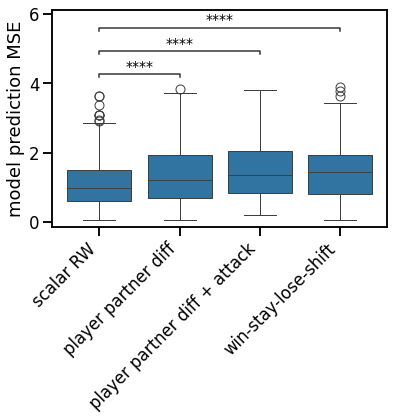

In [88]:
# compare predicted vs predicted step for each model
sim_A['model_prediction_error'] = np.abs(sim_A['prediction_obs'] - sim_A['prediction_argmax'])
sim_B['model_prediction_error'] = np.abs(sim_B['prediction_obs'] - sim_B['prediction_argmax'])
sim_C['model_prediction_error'] = np.abs(sim_C['prediction_obs'] - sim_C['prediction_argmax'])
sim_D['model_prediction_error'] = np.abs(sim_D['prediction_obs'] - sim_D['prediction_argmax']) 
 # bar plot of partner error by model
avg_error = pd.DataFrame({  
    "scalar RW": sim_A.groupby("subID")["model_prediction_error"].mean(),
    "player partner diff": sim_B.groupby("subID")["model_prediction_error"].mean(),
    "player partner diff + attack": sim_C.groupby("subID")["model_prediction_error"].mean(),
    "win-stay-lose-shift": sim_D.groupby("subID")["model_prediction_error"].mean()
}).reset_index().melt(id_vars="subID", var_name="model", value_name="model_prediction_error")

# plot
ax = sns.boxplot(avg_error, x="model", y="model_prediction_error")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_ylabel('model prediction MSE')
ax.set_xlabel('')

# annotate significance on plot: use annotate package
from statannotations.Annotator import Annotator
pairs = [
    ("scalar RW", "player partner diff"),
    ("scalar RW", "player partner diff + attack"),
    ("scalar RW", "win-stay-lose-shift"),
]

annotator = Annotator(
    ax,
    pairs,
    data=avg_error,
    x="model",
    y="model_prediction_error"
)

annotator.configure(
    test="Wilcoxon",
    text_format="star",   # or "simple"
    loc="inside",
    verbose=2,
    fontsize=14
)

annotator.apply_and_annotate()



<Axes: xlabel='model', ylabel='model_partnerStep_error'>

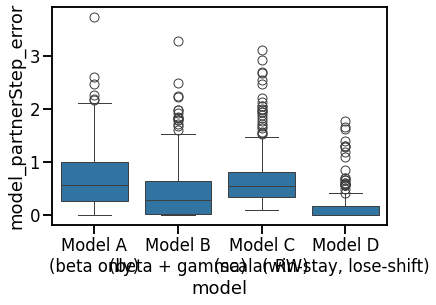

In [89]:

# compare predicted vs actual partner step for each model
plt.figure()
sim_A['model_partnerStep_error'] = np.abs(sim_A['partnerStep_t'] - sim_A['prediction_argmax'])
sim_B['model_partnerStep_error'] = np.abs(sim_B['partnerStep_t'] - sim_B['prediction_argmax'])
sim_C['model_partnerStep_error'] = np.abs(sim_C['partnerStep_t'] - sim_C['prediction_argmax'])
sim_D['model_partnerStep_error'] = np.abs(sim_D['partnerStep_t'] - sim_D['prediction_argmax'])
 # bar plot of partner error by model
avg_error = pd.DataFrame({  
    "Model A\n(beta only)": sim_A.groupby("subID")["model_partnerStep_error"].mean(),
    "Model B\n(beta + gamma)": sim_B.groupby("subID")["model_partnerStep_error"].mean(),
    "Model C\n(scalar RW)": sim_C.groupby("subID")["model_partnerStep_error"].mean(),
    "Model D\n(win-stay, lose-shift)": sim_D.groupby("subID")["model_partnerStep_error"].mean()
}).reset_index().melt(id_vars="subID", var_name="model", value_name="model_partnerStep_error")
sns.boxplot(avg_error, x="model", y="model_partnerStep_error")

(array([27., 38., 21., 30., 24., 20.,  8.,  5.,  8.,  5.,  5.,  8.,  0.,
         5.,  1.,  2.,  1.,  0.,  1.,  1.]),
 array([ 0.05      ,  1.07833333,  2.10666667,  3.135     ,  4.16333333,
         5.19166667,  6.22      ,  7.24833333,  8.27666667,  9.305     ,
        10.33333333, 11.36166667, 12.39      , 13.41833333, 14.44666667,
        15.475     , 16.50333333, 17.53166667, 18.56      , 19.58833333,
        20.61666667]),
 <BarContainer object of 20 artists>)

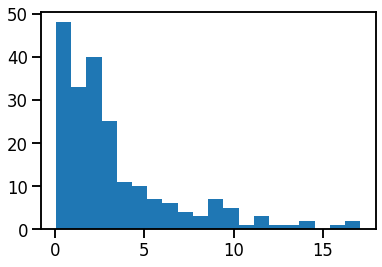

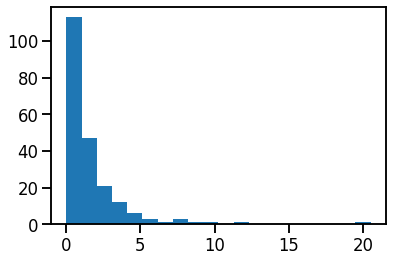

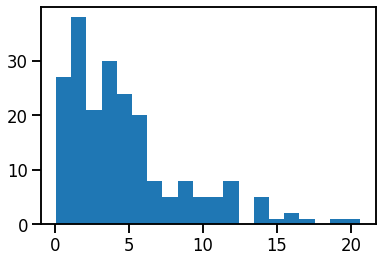

In [90]:
sim_df = sim_A
sim_df['mse'] = (sim_df['prediction_obs'] - sim_df['prediction_argmax']) ** 2
d = sim_df.groupby("subID")["mse"].mean()
plt.figure()
plt.hist(d, bins=20)

# between partner step and simulated prediction
sim_df['mse'] = (sim_df['partnerStep_t'] - sim_df['prediction_argmax']) ** 2
d = sim_df.groupby("subID")["mse"].mean()
plt.figure()
plt.hist(d, bins=20)

# between partner step and real prediction
sim_df['mse'] = (sim_df['partnerStep_t'] - sim_df['prediction_obs']) ** 2
d = sim_df.groupby("subID")["mse"].mean()
plt.figure()
plt.hist(d, bins=20)

# Partial correlation plot

# model fits

In [111]:
folder = "expl" #"conf"
def read_model_df(mname, fname, folder = folder):
    if fname != '':
        fname = '_' + fname
    if folder == "conf":
        rep2 = pd.read_csv(f'../model_fits/rl_rep2/{mname}{fname}.csv')
        rep2['subID']= rep2['subID'] + 400

        df = pd.concat([rep2, pd.read_csv(f"../model_fits/rl_conf/{mname}_conf{fname}.csv")])
    else:
        df = pd.read_csv(f"../model_fits/rl/{mname}{fname}.csv")
        
    return df

# mymodel = "lrflat_peppgFull_econ_ThetaGamma"
# # mymodel2 = "deltaWeightBlame"
# mymodel2 = "arbWeight_llh"
# # mname = f"{mymodel}_{mymodel2}_mserecal"
# mname = f"{mymodel}_{mymodel2}"

# GENRULE, CHOICERULE = mymodel.split("_")[0:2]
# print([GENRULE, CHOICERULE])

# params_df = read_model_df(mname, '', 'expl')
# params_df= params_df.rename({'nll': 'mse'}, axis=1)
# params_df['mse'] = params_df['mse'] * 90 # convert neg log likelihood to mse for AIC/BIC calculation

def mybic(nll, k, N = 176): #176 trials becuase we ignored the first trial for each predator
    return k * np.log(N) + 2 * nll

def myaic(nll, k, N = 176):
    return k * 2 +2 * nll

    
# params_df['bic'] = params_df['nll'].apply(lambda x: mybic(x, 5))
# params_df['aic'] = params_df['nll'].apply(lambda x: myaic(x, 5))

# print(len(params_df))

# print(np.mean(params_df['nll']))

# params_df.head()

In [113]:
# mymodel = "lrhist_peppgFull_econ_ThetaGamma"
# # mymodel2 = "deltaWeightBlame"
# mymodel2 = "arbWeight_llh"
# mname = f"{mymodel}_{mymodel2}"
# mname2 = f"{mymodel}_{mymodel2}"


# params_df2 = read_model_df(mname2, '', 'expl')
# params_df2= params_df2.rename({'nll': 'mse'}, axis=1)
# print(np.mean(params_df2['mse']))

# print(ss.pearsonr(params_df['w'], params_df2['w']))
# print(ss.pearsonr(params_df['alpha'], params_df2['alpha']) )

In [106]:
# #show recovery
# mymodel = "lrflat_peppgFull_econ_ThetaGamma"
# mymodel2 = "arbWeight_llh"
# mname = f"{mymodel}_{mymodel2}"
# print(mname)


# rec_df = read_model_df(mname, 'recovery')
# params_df = read_model_df(mname, '')
# m = pd.merge(params_df, rec_df, on=['subID'])
# # # #if fit by sub:
# # rec_df['subID'] = rec_df['subID']-1
# # rec_df.head()
# print(m.head())

# sns.set_context('talk')
# m['gamma2_x'] = m['gamma_x'] * m['alpha_x']
# m['gamma2_y'] = m['gamma_y'] * m['alpha_y']
# print(len(m))
# col_names = {'alpha':r'learning rate $\alpha$',
#              'theta': r'risk $\theta$',
#              'gamma': r'discount $\gamma$',
#              'w':r'weight $w$'}
# fig, axes = plt.subplots(1, 4, figsize=(16, 4))
# for i, col in enumerate(['alpha', 'theta', 'gamma', 'w']):
#     sns.regplot(data=m, x=col+'_x', y=col+'_y', ax=axes[i], scatter_kws={'s':30, 'alpha':0.2})
#     # axes[i].plot([axes[i].get_xlim()[0], axes[i].get_xlim()[1]], [axes[i].get_ylim()[0], axes[i].get_ylim()[1]], 
#     #              ls='--', lw=1.5)
#     #add title
#     # col = re.sub(r'\d+', '', col)
#     # axes[i].set_title(f"$\{col}$" if col!='w' else f"${col}$")
#     axes[i].set_title(col_names[col])
#     axes[i].set_xlabel('fitted')
#     axes[i].set_ylabel('recovered')
#     print(ss.pearsonr(m[col+'_x'], m[col+'_y']))


    
# plt.tight_layout()
# # if save:
# #     plt.savefig(f'../figs/{folder}/supp_recovery_{mymodel}_{mymodel2}_{folder}.png', 
# #                 bbox_inches='tight', dpi=200)

In [143]:
m1_list = [
        # "realPrediction_lrdecay2_peppg_econ_ThetaGamma",
        # "realPrediction_lrflat_peppg_econ_ThetaGamma",
        "learned_lrdecay2_peppgFull_econ_ThetaGamma",
        "rollingAverage_lrdecay2_peppgFull_econ_ThetaGamma",
        "lrdecay2_peppgFull_econ_ThetaGamma",
        "lrhist_peppgFull_econ_ThetaGamma",
        "lrflat_peppgFull_econ_ThetaGamma",
        ]
m2_list = ["arbWeight_llh"] #"deltaWeight",

all_params_df = pd.DataFrame()
for mymodel in m1_list:
    for mymodel2 in m2_list:
        # params_df = read_model_df(f"{mymodel}_{mymodel2}", '')
        # try:
        mname = f"{mymodel}_{mymodel2}"
        params_df = read_model_df(mname, '')
        shorted_name = ''.join(mname.split("_")[0:-5])
        if shorted_name[:2] == "lr":
             shorted_name = 'realPrediction' + shorted_name
        if shorted_name[-1] == "2":
             shorted_name = shorted_name[:-1]
        params_df['model_name'] = shorted_name
        # params_df = params_df.rename({'nll':'mse'}, axis=1)
        k = 4 if "asIfIdv" not in mymodel2 else 3
        params_df['bic'] = params_df['nll'].apply(lambda x: mybic(x, k))
        params_df['aic'] = params_df['nll'].apply(lambda x: myaic(x, k))
        all_params_df = pd.concat([all_params_df, params_df])
        # except:
        #     pass

print(all_params_df['model_name'].unique())
print(len(all_params_df['subID'].unique()))
# if min(all_params_df['subID'])==1:
#     all_params_df['subID'] = all_params_df['subID'] - 1
# print(f"{len(params_df.subID.unique())} subs with avg nll = {np.mean(params_df.loc[params_df.nll!=np.inf]['nll'])}")
all_params_df.head()




['learnedlrdecay' 'rollingAveragelrdecay' 'realPredictionlrdecay'
 'realPredictionlrhist' 'realPredictionlrflat']
250


,subID,alpha,theta,gamma,w,nll,model_name,bic,aic
0,18,0.51,0.94,0.24,0.18,456.952605,learnedlrdecay,934.587146,921.905210
1,14,0.62,0.64,0.60,-0.35,327.352944,learnedlrdecay,675.387824,662.705888
2,4,0.60,0.51,0.70,0.45,284.958365,learnedlrdecay,590.598666,577.916730
3,0,1.00,0.68,0.78,0.42,254.658798,learnedlrdecay,529.999533,517.317597
4,2,1.00,0.88,0.83,0.60,283.642114,learnedlrdecay,587.966165,575.284229


([0, 1, 2, 3, 4],
 [Text(0, 0, 'realPredictionlrdecay'),
  Text(1, 0, 'realPredictionlrhist'),
  Text(2, 0, 'rollingAveragelrdecay'),
  Text(3, 0, 'learnedlrdecay'),
  Text(4, 0, 'realPredictionlrflat')])

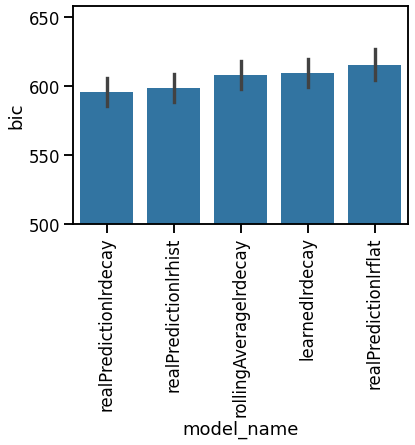

In [144]:
order = all_params_df.groupby('model_name')['bic'].mean().sort_values().index

sns.barplot(data=all_params_df, y='bic', x='model_name', order=order, errorbar='se')
plt.ylim(bottom=500)
plt.xticks(rotation=90)

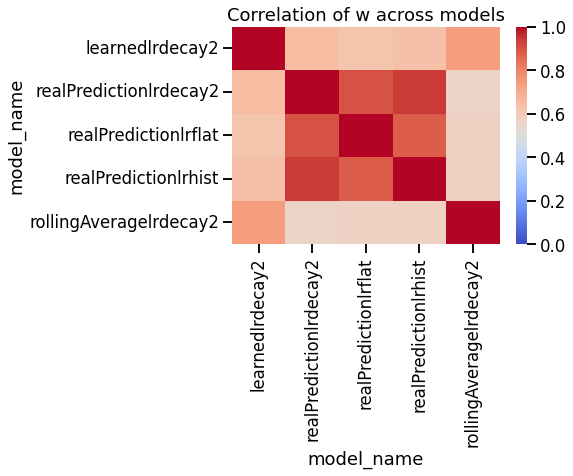

In [139]:
df_wide = all_params_df.pivot(index='subID', columns='model_name', values='w')
corr_matrix = df_wide.corr()
# print(corr_matrix)

# get upper triangle (excluding diagonal)
vals = corr_matrix.values
mean_corr = vals[np.triu_indices_from(vals, k=1)].mean()
# print(mean_corr)

sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', vmin=0, vmax=1)
plt.title("Correlation of w across models")
plt.show()

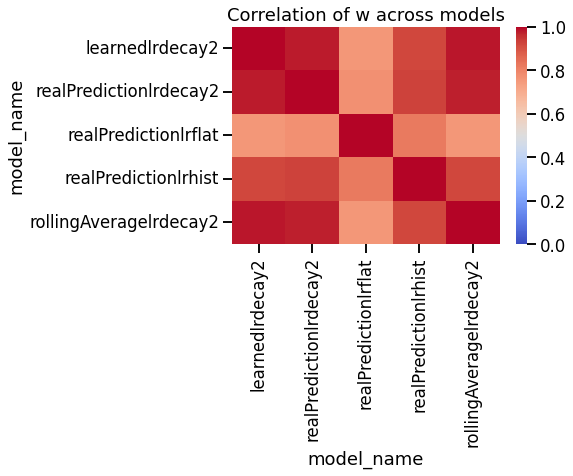

In [138]:
df_wide = all_params_df.pivot(index='subID', columns='model_name', values='theta')
corr_matrix = df_wide.corr()
# print(corr_matrix)

# get upper triangle (excluding diagonal)
vals = corr_matrix.values
mean_corr = vals[np.triu_indices_from(vals, k=1)].mean()
# print(mean_corr)

sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', vmin=0, vmax=1)
plt.title("Correlation of w across models")
plt.show()